In [2]:
import pandas as pd
import numpy as np
from openbb import obb

import datetime as dt
from pandas_datareader import data as pdr
from sklearn.covariance import GraphicalLassoCV
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx
from pylab import rcParams

In [3]:
# Set parameters for data retrieval
num_years = 10
start_date = dt.datetime.now() - dt.timedelta(days=num_years * 365.25)
end_date = dt.datetime.now()

start_date = start_date.strftime('%Y-%m-%d')
end_date = end_date.strftime('%Y-%m-%d')

In [4]:
etfs = {"EWJ": "Japan", "EWZ": "Brazil", "FXI": "China",
        "EWY": "South Korea", "EWT": "Taiwan", "EWH": "Hong Kong",
        "EWC": "Canada", "EWG": "Germany", "EWU": "United Kingdom",
        "EWA": "Australia", "EWW": "Mexico", "EWL": "Switzerland",
        "EWP": "Spain", "EWQ": "France", "EIDO": "Indonesia",
        "ERUS": "Russia", "EWS": "Singapore", "EWM": "Malaysia",
        "EZA": "South Africa", "THD": "Thailand", "ECH": "Chile",
        "EWI": "Italy", "TUR": "Turkey", "EPOL": "Poland",
        "EPHE": "Philippines", "EWD": "Sweden", "EWN": "Netherlands",
        "EPU": "Peru", "ENZL": "New Zealand", "EIS": "Israel",
        "EWO": "Austria", "EIRL": "Ireland", "EWK": "Belgium"}

In [5]:
# Retrieve adjusted close prices for ETFs
symbols = list(etfs.keys())

In [14]:
etfs_data_ = obb.equity.price.historical(
    symbols,
    start_date=start_date,
    end_date=end_date,
    provider="yfinance"
)

In [24]:
print(etfs_data_.head())

             open   high    low  close  volume symbol  dividends  \
date                                                               
2014-03-10  43.04  43.13  42.12  42.40  647500    ECH        0.0   
2014-03-10  26.57  26.70  26.31  26.51  645000   EIDO        0.0   
2014-03-10  40.49  40.49  40.00  40.32   29800   EIRL        0.0   
2014-03-10  51.31  51.54  51.12  51.54   20200    EIS        0.0   
2014-03-10  41.67  41.76  41.43  41.64   16800   ENZL        0.0   

            stock_splits  capital_gains  
date                                     
2014-03-10           0.0            0.0  
2014-03-10           0.0            0.0  
2014-03-10           0.0            0.0  
2014-03-10           0.0            0.0  
2014-03-10           0.0            0.0  


In [29]:
etfs_data_=pd.DataFrame(etfs_data_)

In [30]:
etfs_data = etfs_data_.pivot( columns='symbol', values='close')

print(etfs_data.head())

symbol        ECH   EIDO   EIRL    EIS   ENZL   EPHE   EPOL    EPU   ERUS  \
date                                                                        
2014-03-10  42.40  26.51  40.32  51.54  41.64  34.37  29.47  32.31  34.32   
2014-03-11  41.81  26.42  40.23  51.04  41.39  34.31  28.97  32.21  33.44   
2014-03-12  41.77  26.60  40.27  50.90  41.40  34.26  29.03  32.09  32.98   
2014-03-13  41.72  26.46  39.44  50.77  41.72  33.59  28.06  31.80  31.38   
2014-03-14  41.83  28.05  39.06  50.94  41.63  33.64  28.34  31.97  32.72   

symbol        EWA  ...    EWS    EWT    EWU    EWW    EWY    EWZ    EZA  \
date               ...                                                    
2014-03-10  25.17  ...  25.34  28.38  41.54  60.55  60.53  39.63  63.98   
2014-03-11  24.92  ...  25.18  28.16  41.34  60.15  60.15  39.38  62.74   
2014-03-12  24.92  ...  25.24  28.48  41.10  60.35  59.77  39.68  63.33   
2014-03-13  24.91  ...  24.74  28.22  40.44  59.14  58.76  39.22  62.35   
2014-03-14

In [31]:
# Convert prices to log returns
log_returns = np.log1p(etfs_data.pct_change()).dropna()
print(log_returns.head())

symbol           ECH      EIDO      EIRL       EIS      ENZL      EPHE  \
date                                                                     
2014-03-11 -0.014013 -0.003401 -0.002235 -0.009749 -0.006022 -0.001747   
2014-03-12 -0.000957  0.006790  0.000994 -0.002747  0.000242 -0.001458   
2014-03-13 -0.001198 -0.005277 -0.020826 -0.002557  0.007700 -0.019750   
2014-03-14  0.002633  0.058354 -0.009682  0.003343 -0.002160  0.001487   
2014-03-17  0.008095  0.015915  0.018014  0.015196  0.012414  0.017387   

symbol          EPOL       EPU      ERUS       EWA  ...       EWS       EWT  \
date                                                ...                       
2014-03-11 -0.017112 -0.003100 -0.025975 -0.009982  ... -0.006334 -0.007782   
2014-03-12  0.002069 -0.003733 -0.013851  0.000000  ...  0.002380  0.011300   
2014-03-13 -0.033985 -0.009078 -0.049731 -0.000401  ... -0.020009 -0.009171   
2014-03-14  0.009929  0.005332  0.041816 -0.008061  ...  0.007249  0.002124   
2014-03

In [37]:
# Normalize and fit Graphical Lasso model
log_returns_normalized = log_returns / log_returns.std(axis=0).dropna()

#convert to numpy array
log_returns_normalized = log_returns_normalized.to_numpy()

In [40]:
import warnings
warnings.filterwarnings("ignore")

edge_model = GraphicalLassoCV(cv=10)
edge_model.fit(log_returns_normalized)

GraphicalLassoCV(cv=10)

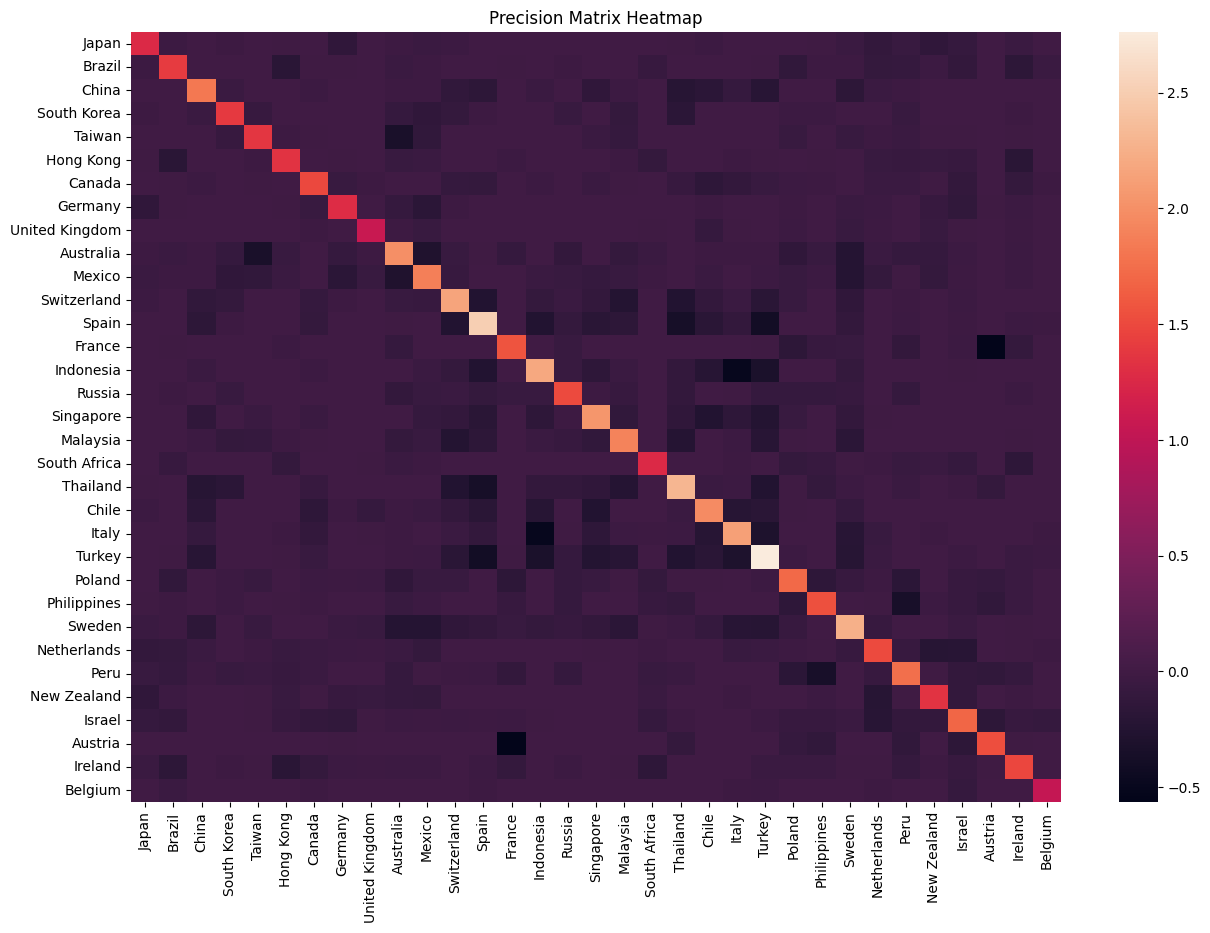

In [41]:
# Plot precision matrix as heatmap
rcParams['figure.figsize'] = 15, 10
sns.heatmap(edge_model.precision_, xticklabels=etfs.values(), yticklabels=etfs.values())
plt.title('Precision Matrix Heatmap')
plt.show()

In [45]:
# Prepare data for network graph
precision_df = pd.DataFrame(edge_model.precision_, index=etfs.keys(), columns=etfs.keys())
links = precision_df.stack().reset_index()
links.columns = ['ETF1', 'ETF2', 'Value']
links_filtered = links[(abs(links['Value']) > 0.17) & (links['ETF1'] != links['ETF2'])]

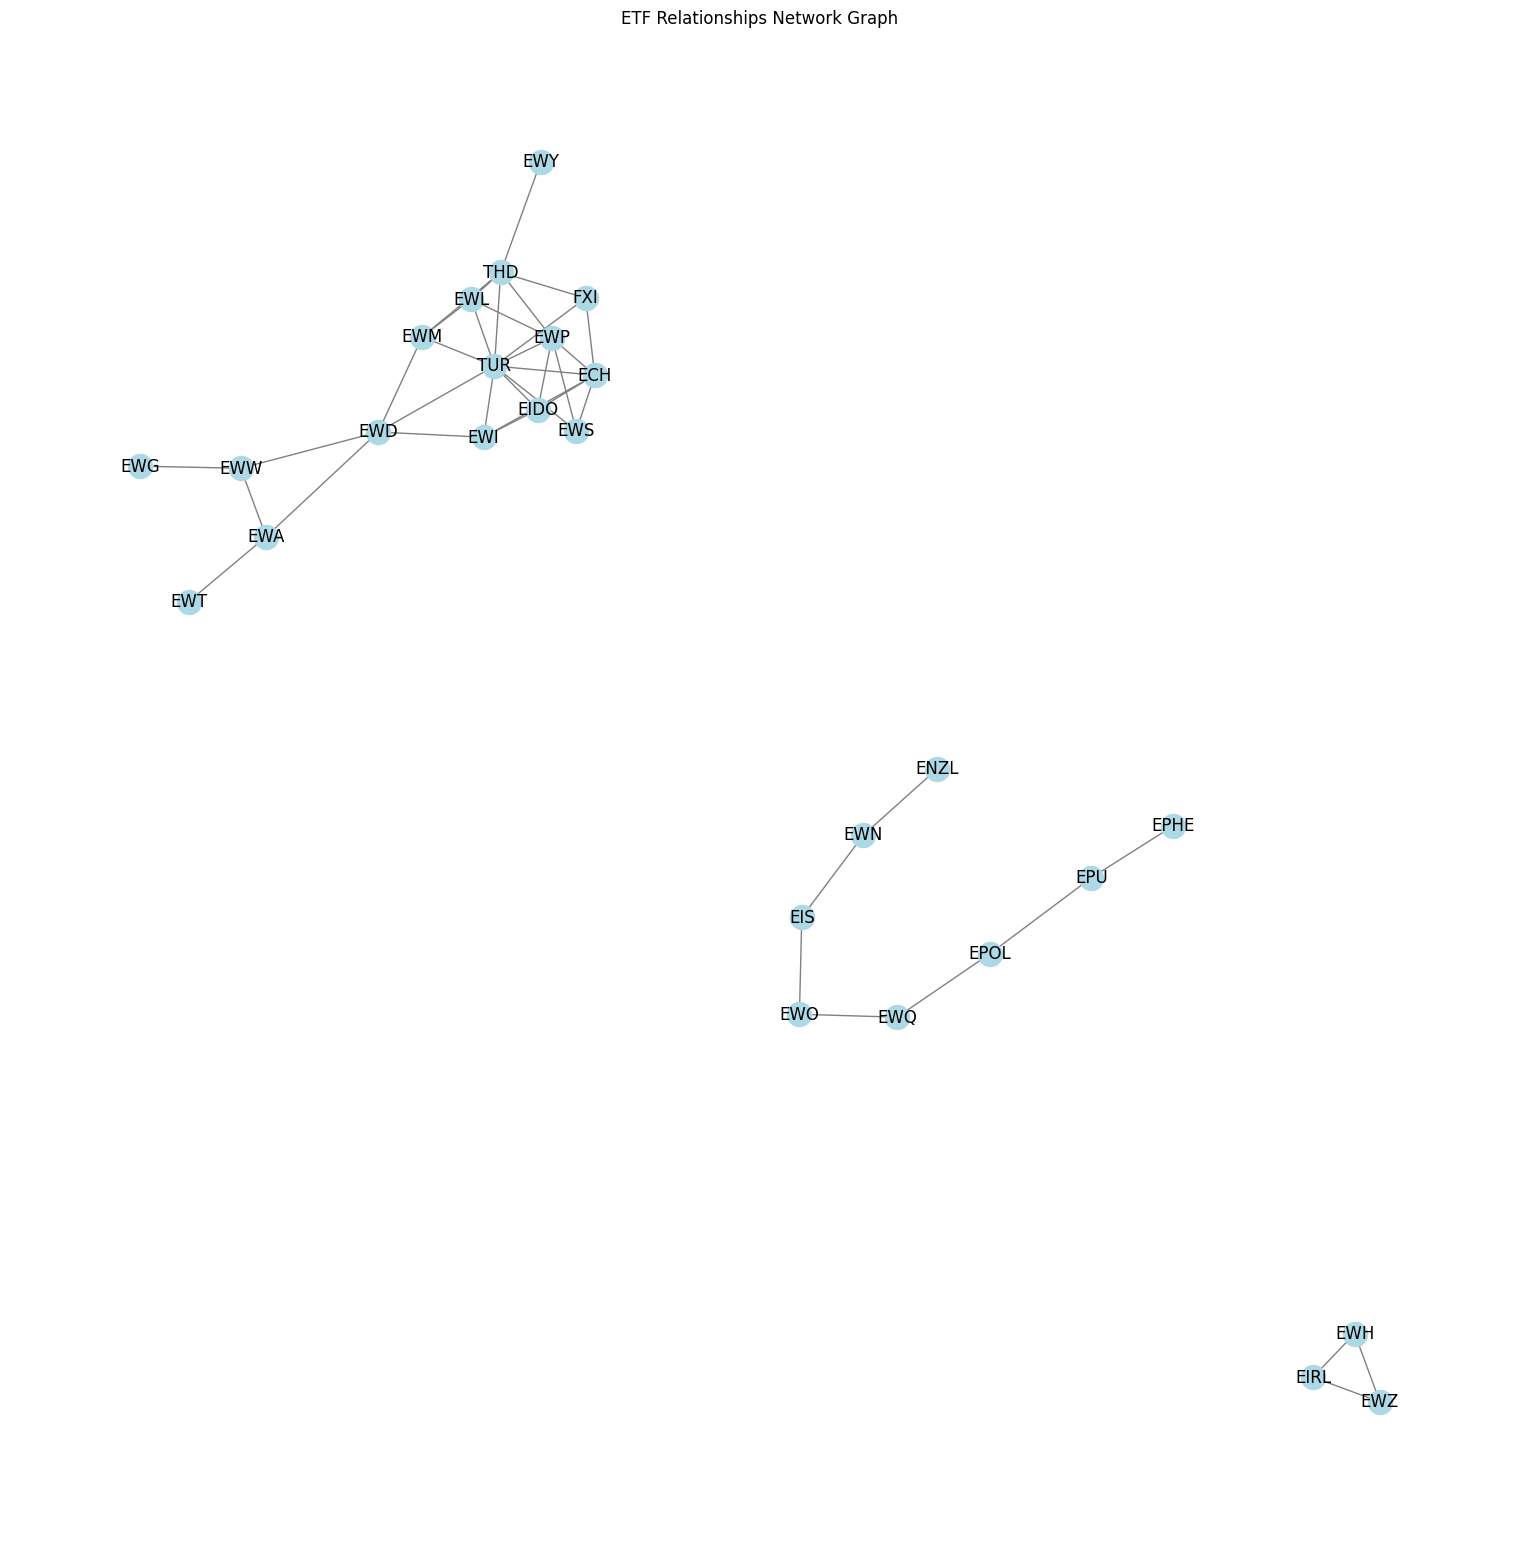

In [43]:
# Build and display the network graph
G = nx.from_pandas_edgelist(links_filtered, 'ETF1', 'ETF2')
pos = nx.spring_layout(G, k=0.2 * 1 / np.sqrt(len(G.nodes())), iterations=20)
plt.figure(figsize=(15, 15))
nx.draw(G, pos=pos, with_labels=True, node_color='lightblue', edge_color='grey')
plt.title('ETF Relationships Network Graph')
plt.show()